# Rezagos, diferencias y ventanas temporales

## Tópicos Selectos de Matemáticas Aplicadas II

En el notebook anterior construimos un panel multivariado horario que combina concentraciones de ozono y temperatura para cuatro estaciones de monitoreo:

$$
\text{MER},\qquad
\text{MGH},\qquad
\text{PED},\qquad
\text{UAX}.
$$

Cada observación puede representarse como

$$
(i,t,Y_{i,t},T_{i,t}),
$$

donde:

- $i$ representa la estación;
- $t$ representa la hora;
- $Y_{i,t}$ es la concentración de O$_3$;
- $T_{i,t}$ es la temperatura.

En este notebook incorporaremos una idea fundamental en el análisis de series temporales:

**el valor observado en un instante puede relacionarse con lo que ocurrió anteriormente.**



## Rezagos

Un rezago de orden $k$ se define como

$$
Y_{t-k}.
$$

Por ejemplo:

$$
Y_{t-1}
$$

representa el valor observado una hora antes, mientras que

$$
Y_{t-24}
$$

representa el valor observado a la misma hora del día anterior.



## Diferencias

También podemos estudiar cuánto cambió una variable entre dos instantes consecutivos:

$$
\Delta Y_t
=
Y_t-Y_{t-1}.
$$

Si

$$
\Delta Y_t>0,
$$

la concentración aumentó respecto a la hora anterior, mientras que

$$
\Delta Y_t<0
$$

indica una disminución.



## Ventanas temporales

En lugar de utilizar una sola observación pasada, también podemos resumir un conjunto de observaciones recientes.

Por ejemplo, una media móvil de tamaño $w$ se define como

$$
\overline{Y}_t^{(w)}
=\frac{1}{w}
\sum_{j=0}^{w-1}Y_{t-j}.
$$

Esto permite describir el comportamiento reciente de la serie utilizando características como:

- media;
- mediana;
- mínimo;
- máximo;
- desviación estándar;
- rango.



## Objetivos

En este notebook aprenderemos a:

- construir rezagos temporales;
- interpretar rezagos horarios y diarios;
- calcular diferencias y cambios temporales;
- construir medias y estadísticas móviles;
- aplicar estas operaciones correctamente dentro de cada estación;
- identificar los valores faltantes generados por rezagos y ventanas;
- enriquecer un panel temporal con nuevas características.

El flujo principal será

$$
\boxed{
Y_t
\rightarrow
Y_{t-k}
\rightarrow
\Delta Y_t
\rightarrow
\text{ventanas móviles}
\rightarrow
\text{características temporales}
}
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
ruta = 'https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/panel_o3_temperatura_2026.csv'

panel = pd.read_csv(
    ruta,
    parse_dates=["timestamp", "fecha"])


# Orden temporal dentro de cada estación
panel = panel.sort_values(["estacion", "timestamp"]).reset_index(drop=True)
panel

,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad,temperatura,temperatura_imputada
0,2026-01-01 01:00:00,2026-01-01,1,MER,7.0,False,False,15.0,False
1,2026-01-01 02:00:00,2026-01-01,2,MER,3.0,False,False,14.1,False
2,2026-01-01 03:00:00,2026-01-01,3,MER,3.0,False,False,12.5,False
3,2026-01-01 04:00:00,2026-01-01,4,MER,3.0,False,False,11.9,False
4,2026-01-01 05:00:00,2026-01-01,5,MER,4.0,False,False,11.1,False
...,...,...,...,...,...,...,...,...,...
5659,2026-02-28 20:00:00,2026-02-28,20,UAX,42.0,False,False,23.0,False
5660,2026-02-28 21:00:00,2026-02-28,21,UAX,28.0,False,False,21.6,False
5661,2026-02-28 22:00:00,2026-02-28,22,UAX,19.0,False,False,20.4,False
5662,2026-02-28 23:00:00,2026-02-28,23,UAX,5.0,False,False,19.7,False


## Construcción de series diarias de O$_3$ y temperatura

El panel contiene mediciones horarias de ozono y temperatura para cuatro estaciones.

Para simplificar el estudio de rezagos, diferencias y ventanas móviles construiremos dos series temporales diarias:

$$
O_{3,d}
=
\frac{1}{N_d}
\sum O_{3,i,t},
$$

y

$$
T_d
=
\frac{1}{N_d}
\sum T_{i,t},
$$

donde el promedio considera las observaciones correspondientes al día $d$ y a las estaciones seleccionadas.

De esta manera, para cada día tendremos únicamente dos valores:

$$
\boxed{
(\text{fecha},\;O_{3,d},\;T_d)
}
$$

El cambio de frecuencia horaria a diaria reduce las fluctuaciones dentro de cada día y facilita la interpretación de conceptos como:

- rezago de un día: $Y_{t-1}$;
- rezago de una semana: $Y_{t-7}$;
- diferencia diaria: $Y_t-Y_{t-1}$;
- media móvil de $3$ días;
- media móvil de $7$ días.

El periodo disponible contiene $59$ días, suficientes para introducir estas transformaciones temporales.

Estas series representan el promedio de las cuatro estaciones seleccionadas y no necesariamente el comportamiento espacial de toda la Ciudad de México.

In [3]:
# Promedios diarios de O3 y temperatura

serie_diaria = (
    panel
    .groupby("fecha", as_index=False)
    .agg(
        o3_promedio=("o3", "mean"),
        temperatura_promedio=("temperatura", "mean"))
    .sort_values("fecha")
    .reset_index(drop=True)
)
serie_diaria.head(10)

,fecha,o3_promedio,temperatura_promedio
0,2026-01-01,33.989583,15.309375
1,2026-01-02,35.244792,15.318750
2,2026-01-03,33.083333,16.020833
3,2026-01-04,36.125000,15.860417
4,2026-01-05,37.993212,16.252083
5,2026-01-06,36.765121,16.697917
6,2026-01-07,39.322917,16.664583
7,2026-01-08,38.343750,16.436458
8,2026-01-09,29.947917,16.215625
9,2026-01-10,32.166667,15.102083


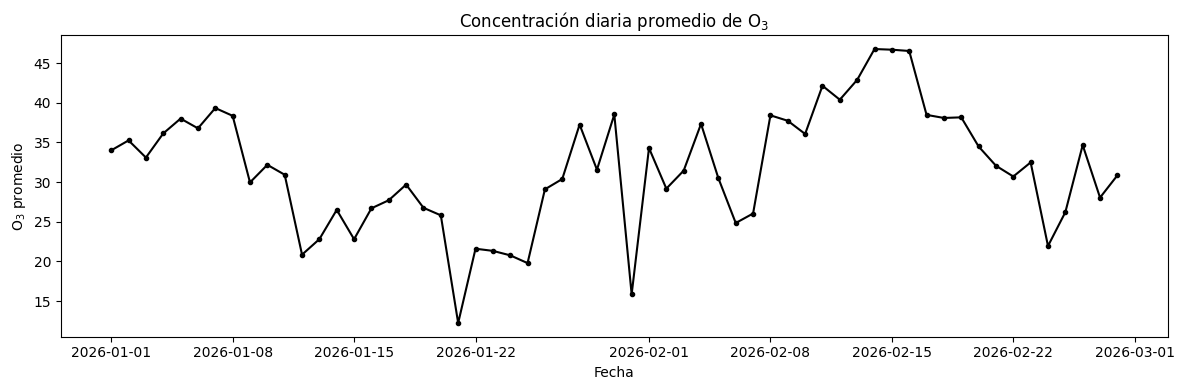

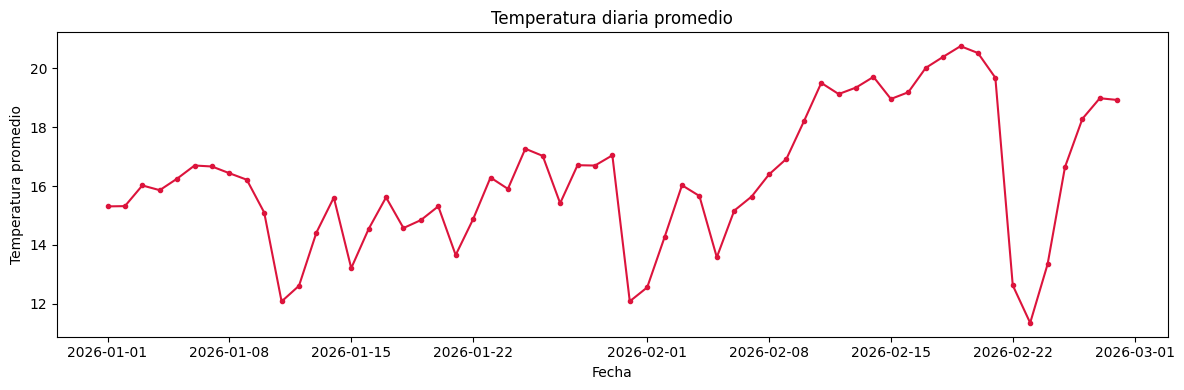

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    color='black'
)

ax.set_title("Concentración diaria promedio de O$_3$")
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["temperatura_promedio"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    color='crimson'
)

ax.set_title("Temperatura diaria promedio")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura promedio")

plt.tight_layout()
plt.show()

## Rezagos de una serie temporal diaria

Un rezago permite incorporar información del pasado de una serie.

Para una variable diaria $Y_t$, el rezago de orden $k$ se define como

$$
Y_{t-k}.
$$

En nuestro caso:

$$
O_{3,t-1}
$$

representa la concentración promedio de ozono del **día anterior**, mientras que

$$
O_{3,t-7}
$$

representa la concentración observada **siete días antes**.

De manera similar, para la temperatura podemos construir

$$
T_{t-1}
\qquad\text{y}\qquad
T_{t-7}.
$$

Los rezagos son especialmente importantes porque permiten estudiar si el estado actual de una serie está relacionado con su comportamiento pasado.

En `pandas` se construyen mediante `shift()`:

```python
serie.shift(k)

In [5]:
# Rezagos diarios de O3

serie_diaria["o3_lag_1"] = serie_diaria["o3_promedio"].shift(1) # 1 día

serie_diaria["o3_lag_7"] = serie_diaria["o3_promedio"].shift(7) # 7 días


# Rezagos diarios de temperatura

serie_diaria["temp_lag_1"] = serie_diaria["temperatura_promedio"].shift(1)

serie_diaria["temp_lag_7"] = serie_diaria["temperatura_promedio"].shift(7)

display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "o3_lag_1",
            "o3_lag_7",
            "temperatura_promedio",
            "temp_lag_1",
            "temp_lag_7"
        ]
    ].head(12)
)

,fecha,o3_promedio,o3_lag_1,o3_lag_7,temperatura_promedio,temp_lag_1,temp_lag_7
0,2026-01-01,33.989583,NaN,NaN,15.309375,NaN,NaN
1,2026-01-02,35.244792,33.989583,NaN,15.318750,15.309375,NaN
2,2026-01-03,33.083333,35.244792,NaN,16.020833,15.318750,NaN
3,2026-01-04,36.125000,33.083333,NaN,15.860417,16.020833,NaN
4,2026-01-05,37.993212,36.125000,NaN,16.252083,15.860417,NaN
5,2026-01-06,36.765121,37.993212,NaN,16.697917,16.252083,NaN
6,2026-01-07,39.322917,36.765121,NaN,16.664583,16.697917,NaN
7,2026-01-08,38.343750,39.322917,33.989583,16.436458,16.664583,15.309375
8,2026-01-09,29.947917,38.343750,35.244792,16.215625,16.436458,15.318750
9,2026-01-10,32.166667,29.947917,33.083333,15.102083,16.215625,16.020833


## Relación entre el valor actual y sus rezagos

Una forma sencilla de explorar la **dependencia temporal** consiste en comparar el valor actual de la serie con sus propios valores pasados.

Para un rezago de un día estudiaremos la relación entre

$$
O_{3,t}
\qquad\text{y}\qquad
O_{3,t-1}.
$$

Para un rezago semanal compararemos

$$
O_{3,t}
\qquad\text{y}\qquad
O_{3,t-7}.
$$

Si existe una relación positiva fuerte, los días con concentraciones altas tenderán a estar precedidos por valores también altos.

Como resumen numérico podemos calcular

$$
r_k=
\operatorname{Corr}
\left(
O_{3,t},
O_{3,t-k}
\right).
$$

Un valor de $r_k$ cercano a $1$ indica una asociación lineal positiva fuerte entre la serie actual y su rezago.

Un valor cercano a $0$ indica poca asociación lineal.

En esta sección utilizaremos únicamente estos coeficientes como una primera descripción de la memoria temporal de la serie. El estudio formal mediante funciones de autocorrelación se realizará posteriormente.

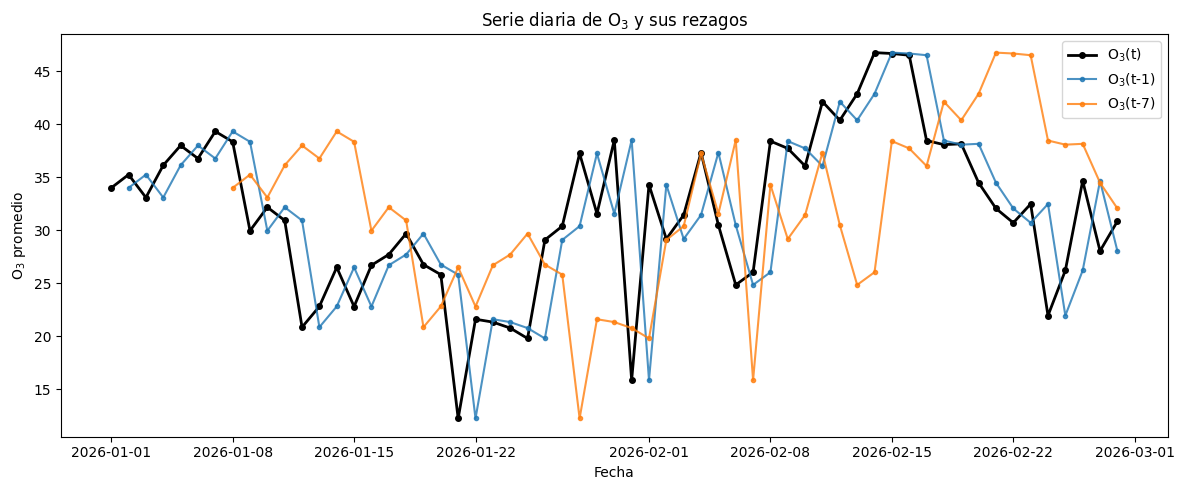

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    marker="o",
    markersize=4,
    linewidth=2,
    label="O$_3$(t)",
    color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_lag_1"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    alpha=0.8,
    label="O$_3$(t-1)"
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_lag_7"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    alpha=0.8,
    label="O$_3$(t-7)"
)

ax.set_title("Serie diaria de O$_3$ y sus rezagos")

ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")

ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Correlación con los rezagos

r_lag_1 = serie_diaria["o3_promedio"].corr(serie_diaria["o3_lag_1"], method="spearman")

r_lag_7 = serie_diaria["o3_promedio"].corr(serie_diaria["o3_lag_7"], method="spearman")


print("Correlación O3(t) vs O3(t-1):")
print(f"{r_lag_1:.3f}")

print("\nCorrelación O3(t) vs O3(t-7):")
print(f"{r_lag_7:.3f}")

Correlación O3(t) vs O3(t-1):
0.663

Correlación O3(t) vs O3(t-7):
0.151


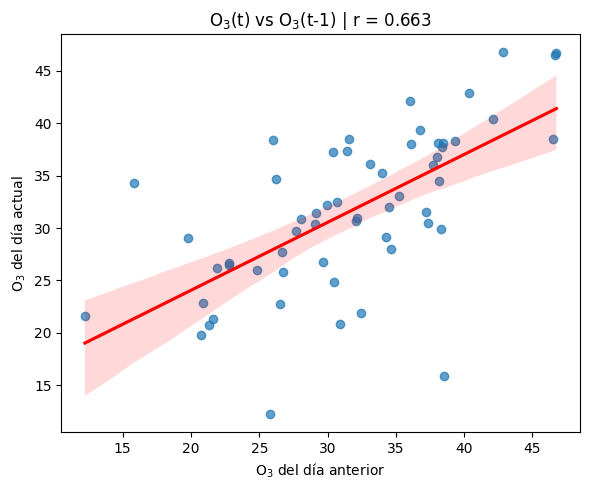

In [8]:
import seaborn as sns 

datos_lag1 = serie_diaria[["o3_promedio", "o3_lag_1"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))

sns.regplot(
    data=datos_lag1,
    x="o3_lag_1",
    y="o3_promedio",
    ax=ax,
    scatter_kws={"alpha": 0.7},  
    line_kws={"color": "red"},  
)

ax.set_xlabel("O$_3$ del día anterior")
ax.set_ylabel("O$_3$ del día actual")
ax.set_title(f"O$_3$(t) vs O$_3$(t-1) | r = {r_lag_1:.3f}")

plt.tight_layout()
plt.show()

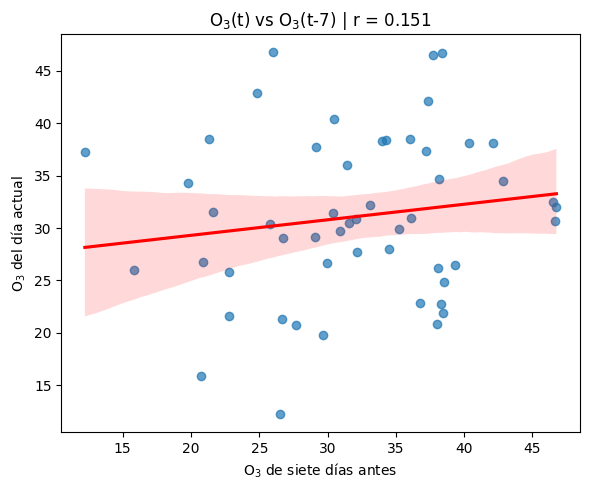

In [9]:
datos_lag7 = serie_diaria[["o3_promedio", "o3_lag_7"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))

# Usamos regplot para incluir el diagrama de dispersión y la línea de tendencia
sns.regplot(
    data=datos_lag7,
    x="o3_lag_7",
    y="o3_promedio",
    ax=ax,
    scatter_kws={"alpha": 0.7},  # Mantiene la transparencia de los puntos
    line_kws={"color": "red"},  # Mantiene la línea de regresión roja
)

ax.set_xlabel("O$_3$ de siete días antes")
ax.set_ylabel("O$_3$ del día actual")

ax.set_title(f"O$_3$(t) vs O$_3$(t-7) | r = {r_lag_7:.3f}")

plt.tight_layout()
plt.show()

## Diferencias diarias

Un rezago conserva el valor observado en el pasado. Una **diferencia**, en cambio, mide cuánto cambió la serie entre dos instantes consecutivos.

Para el ozono definimos

$$
\Delta O_{3,t}
=
O_{3,t}-O_{3,t-1}.
$$

La interpretación es directa:

$$
\Delta O_{3,t}>0
$$

indica que la concentración promedio de O$_3$ aumentó respecto al día anterior;

$$
\Delta O_{3,t}<0
$$

indica que disminuyó;

y

$$
\Delta O_{3,t}=0
$$

indica que no hubo cambio.

Por ejemplo, si

$$
O_{3,t-1}=30
$$

y

$$
O_{3,t}=38,
$$

entonces

$$
\Delta O_{3,t}=38-30=8.
$$

También podemos definir la diferencia diaria de temperatura:

$$
\Delta T_t=
T_t-T_{t-1}.
$$



In [10]:
# Diferencias diarias

serie_diaria["delta_o3"] = serie_diaria["o3_promedio"].diff()

serie_diaria["delta_temp"] = serie_diaria["temperatura_promedio"].diff()

print("Primeras observaciones:")

display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "o3_lag_1",
            "delta_o3",
            "temperatura_promedio",
            "temp_lag_1",
            "delta_temp"
        ]
    ].head(10)
)

Primeras observaciones:


,fecha,o3_promedio,o3_lag_1,delta_o3,temperatura_promedio,temp_lag_1,delta_temp
0,2026-01-01,33.989583,NaN,NaN,15.309375,NaN,NaN
1,2026-01-02,35.244792,33.989583,1.255208,15.318750,15.309375,0.009375
2,2026-01-03,33.083333,35.244792,-2.161458,16.020833,15.318750,0.702083
3,2026-01-04,36.125000,33.083333,3.041667,15.860417,16.020833,-0.160417
4,2026-01-05,37.993212,36.125000,1.868212,16.252083,15.860417,0.391667
5,2026-01-06,36.765121,37.993212,-1.228091,16.697917,16.252083,0.445833
6,2026-01-07,39.322917,36.765121,2.557796,16.664583,16.697917,-0.033333
7,2026-01-08,38.343750,39.322917,-0.979167,16.436458,16.664583,-0.228125
8,2026-01-09,29.947917,38.343750,-8.395833,16.215625,16.436458,-0.220833
9,2026-01-10,32.166667,29.947917,2.218750,15.102083,16.215625,-1.113542


In [11]:
# Resumen de los cambios

print("\nResumen de las diferencias diarias:")
serie_diaria[["delta_o3", "delta_temp"]].describe().round(2)


Resumen de las diferencias diarias:


,delta_o3,delta_temp
count,58.00,58.00
mean,-0.05,0.06
std,6.37,1.64
min,-22.67,-7.05
25%,-2.36,-0.33
50%,-0.12,0.36
75%,2.74,1.16
max,18.44,3.30


In [12]:
# Días con mayor aumento y disminución de O3

mayor_aumento = serie_diaria.loc[serie_diaria["delta_o3"].idxmax()]

mayor_disminucion = serie_diaria.loc[serie_diaria["delta_o3"].idxmin()]

print("\nMayor aumento diario de O3:")
print(mayor_aumento["fecha"]," | cambio = ",round(mayor_aumento["delta_o3"], 2))

print("\nMayor disminución diaria de O3:")
print(mayor_disminucion["fecha"]," | cambio = ",round(mayor_disminucion["delta_o3"], 2))


Mayor aumento diario de O3:
2026-02-01 00:00:00  | cambio =  18.44

Mayor disminución diaria de O3:
2026-01-31 00:00:00  | cambio =  -22.67


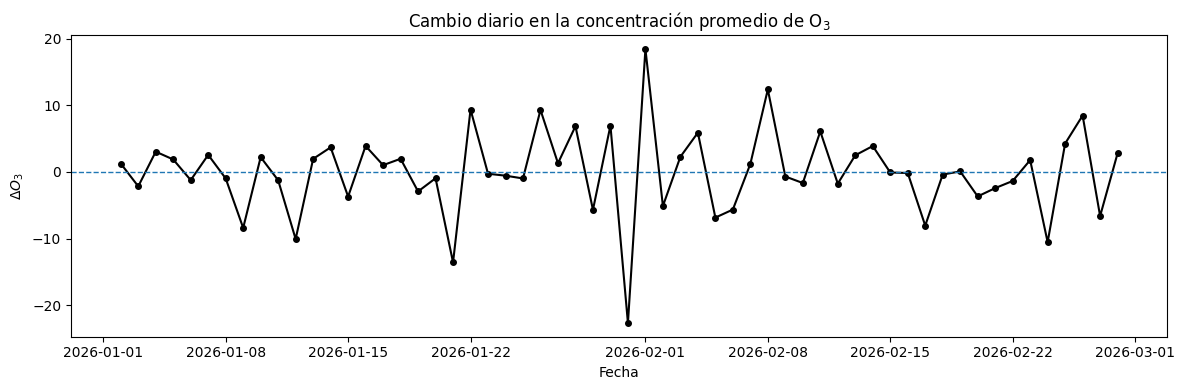

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["delta_o3"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color='black'
)

ax.axhline(0,linestyle="--",linewidth=1)
ax.set_title("Cambio diario en la concentración promedio de O$_3$")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta O_3$")

plt.tight_layout()
plt.show()

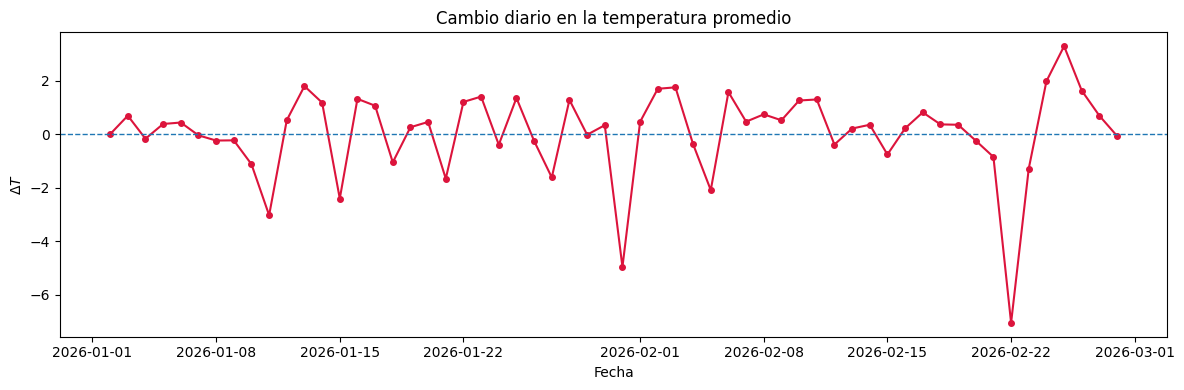

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["delta_temp"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color='crimson'
)

ax.axhline(0,linestyle="--",linewidth=1)
ax.set_title("Cambio diario en la temperatura promedio")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta T$")

plt.tight_layout()
plt.show()

## Tasas de cambio

La diferencia

$$
\Delta Y_t = Y_t-Y_{t-1}
$$

mide el cambio absoluto entre dos días consecutivos.

Sin embargo, un aumento de $5$ unidades puede tener significados diferentes dependiendo del nivel inicial.

Por ejemplo:

- pasar de $10$ a $15$ representa un cambio importante;
- pasar de $50$ a $55$ representa el mismo aumento absoluto, pero un cambio relativo menor.

Por esta razón podemos calcular la **tasa de cambio porcentual**:

$$
R_t=\frac{Y_t-Y_{t-1}}{Y_{t-1}}\times100.
$$

Para el ozono:

$$
R^{O_3}_t=
\frac{
O_{3,t}-O_{3,t-1}
}{
O_{3,t-1}
}
\times100.
$$

Si

$$
R_t>0,
$$

la variable aumentó respecto al día anterior.

Si

$$
R_t<0,
$$

la variable disminuyó.

Por ejemplo, si el O$_3$ promedio cambia de $20$ a $25$:

$$
R_t=\frac{25-20}{20}\times100=25\%.
$$

In [15]:
# Tasas de cambio porcentual

serie_diaria["cambio_pct_o3"] = serie_diaria["o3_promedio"].pct_change() * 100

serie_diaria["cambio_pct_temp"] = serie_diaria["temperatura_promedio"].pct_change() * 100

# Inspección
display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "delta_o3",
            "cambio_pct_o3",
            "temperatura_promedio",
            "delta_temp",
            "cambio_pct_temp"
        ]
    ].head(10)
)

,fecha,o3_promedio,delta_o3,cambio_pct_o3,temperatura_promedio,delta_temp,cambio_pct_temp
0,2026-01-01,33.989583,NaN,NaN,15.309375,NaN,NaN
1,2026-01-02,35.244792,1.255208,3.692921,15.318750,0.009375,0.061237
2,2026-01-03,33.083333,-2.161458,-6.132703,16.020833,0.702083,4.583163
3,2026-01-04,36.125000,3.041667,9.193955,15.860417,-0.160417,-1.001300
4,2026-01-05,37.993212,1.868212,5.171522,16.252083,0.391667,2.469460
5,2026-01-06,36.765121,-1.228091,-3.232397,16.697917,0.445833,2.743238
6,2026-01-07,39.322917,2.557796,6.957126,16.664583,-0.033333,-0.199626
7,2026-01-08,38.343750,-0.979167,-2.490066,16.436458,-0.228125,-1.368921
8,2026-01-09,29.947917,-8.395833,-21.896224,16.215625,-0.220833,-1.343558
9,2026-01-10,32.166667,2.218750,7.408696,15.102083,-1.113542,-6.867091


In [16]:
print("Resumen de las tasas de cambio porcentual:")

serie_diaria[["cambio_pct_o3","cambio_pct_temp"]].describe().round(2)

Resumen de las tasas de cambio porcentual:


,cambio_pct_o3,cambio_pct_temp
count,58.00,58.00
mean,2.89,0.92
std,26.15,10.14
min,-58.86,-35.82
25%,-6.81,-1.81
50%,-0.26,1.88
75%,9.16,7.34
max,116.37,24.75


In [17]:
# Mayor aumento y disminución porcentual de O3

mayor_aumento_pct = serie_diaria.loc[serie_diaria["cambio_pct_o3"].idxmax()]

mayor_disminucion_pct = serie_diaria.loc[serie_diaria["cambio_pct_o3"].idxmin()]


print("\nMayor aumento porcentual de O3:")
print(mayor_aumento_pct["fecha"]," | ",f'{mayor_aumento_pct["cambio_pct_o3"]:.2f}%')

print("\nMayor disminución porcentual de O3:")
print(mayor_disminucion_pct["fecha"]," | ",f'{mayor_disminucion_pct["cambio_pct_o3"]:.2f}%')


Mayor aumento porcentual de O3:
2026-02-01 00:00:00  |  116.37%

Mayor disminución porcentual de O3:
2026-01-31 00:00:00  |  -58.86%


El 116.37 % del 1 de febrero no significa un valor de O$_3$ extraordinariamente alto por sí mismo, sino que el promedio fue más del doble que el día anterior.

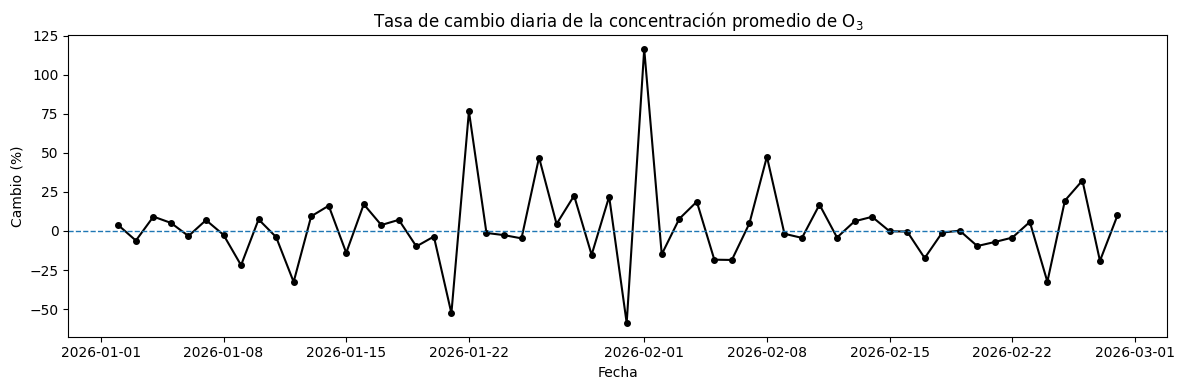

In [18]:
# Gráfica de cambio porcentual del O3

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["cambio_pct_o3"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color='black'
)

ax.axhline(0,linestyle="--",linewidth=1)
ax.set_title("Tasa de cambio diaria de la concentración promedio de O$_3$")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cambio (%)")

plt.tight_layout()
plt.show()

### Interpretación

Las tasas de cambio permiten comparar variaciones relativas entre días.

En el periodo analizado, el mayor incremento de O$_3$ fue de $116.37\%$ el 1 de febrero, mientras que la mayor disminución fue de $-58.86\%$ el 31 de enero.

Los cambios porcentuales pueden alcanzar valores elevados cuando el nivel del día anterior es relativamente bajo. Por ello, conviene interpretar conjuntamente: $\Delta O_{3,t}$ y $R^{O_3}_t,$
es decir, el cambio absoluto y el cambio relativo.

## Ventanas móviles

Hasta ahora hemos utilizado observaciones individuales del pasado:

$$
Y_{t-1},
\qquad
Y_{t-7}.
$$

Sin embargo, en muchos problemas interesa resumir el comportamiento de varios días recientes.

Una **ventana móvil** de tamaño $w$ considera las últimas $w$ observaciones:

$$
Y_t,\;
Y_{t-1},\;
\ldots,\;
Y_{t-w+1}.
$$

Por ejemplo, una ventana de $3$ días contiene

$$
Y_t,\;Y_{t-1},\;Y_{t-2}.
$$

La media móvil de tamaño $w$ se define como

$$
\overline{Y}^{(w)}_t=
\frac{1}{w}
\sum_{j=0}^{w-1}Y_{t-j}.
$$

Construiremos dos medias móviles para el O$_3$:

$$
\overline{O_3}^{(3)}_t
$$

y

$$
\overline{O_3}^{(7)}_t.
$$

La primera responde a la pregunta: **¿Cuál ha sido el nivel promedio de O$_3$ durante los últimos tres días?**

La segunda resume el comportamiento de la última semana.

Una ventana más grande produce una serie más suave, pero también responde más lentamente a cambios repentinos.

In [19]:
# Medias móviles de O3

serie_diaria["o3_media_3d"] = serie_diaria["o3_promedio"].rolling(window=3,min_periods=3).mean()

serie_diaria["o3_media_7d"] = serie_diaria["o3_promedio"].rolling(window=7,min_periods=7).mean()


# Medias móviles de temperatura

serie_diaria["temp_media_3d"] = (
    serie_diaria["temperatura_promedio"]
    .rolling(window=3,min_periods=3)
    .mean()
)

serie_diaria["temp_media_7d"] = (
    serie_diaria["temperatura_promedio"]
    .rolling(
        window=7,
        min_periods=7
    )
    .mean()
)


display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "o3_media_3d",
            "o3_media_7d",
            "temperatura_promedio",
            "temp_media_3d",
            "temp_media_7d"
        ]
    ].head(10)
)

,fecha,o3_promedio,o3_media_3d,o3_media_7d,temperatura_promedio,temp_media_3d,temp_media_7d
0,2026-01-01,33.989583,NaN,NaN,15.309375,NaN,NaN
1,2026-01-02,35.244792,NaN,NaN,15.318750,NaN,NaN
2,2026-01-03,33.083333,34.105903,NaN,16.020833,15.549653,NaN
3,2026-01-04,36.125000,34.817708,NaN,15.860417,15.733333,NaN
4,2026-01-05,37.993212,35.733849,NaN,16.252083,16.044444,NaN
5,2026-01-06,36.765121,36.961111,NaN,16.697917,16.270139,NaN
6,2026-01-07,39.322917,38.027083,36.074851,16.664583,16.538194,16.017708
7,2026-01-08,38.343750,38.143929,36.696875,16.436458,16.599653,16.178720
8,2026-01-09,29.947917,35.871528,35.940179,16.215625,16.438889,16.306845
9,2026-01-10,32.166667,33.486111,35.809226,15.102083,15.918056,16.175595


In [29]:
v = serie_diaria['o3_promedio'].loc[1:3]
print(v)
v.mean().round(2)

1    35.244792
2    33.083333
3    36.125000
Name: o3_promedio, dtype: float64


34.82

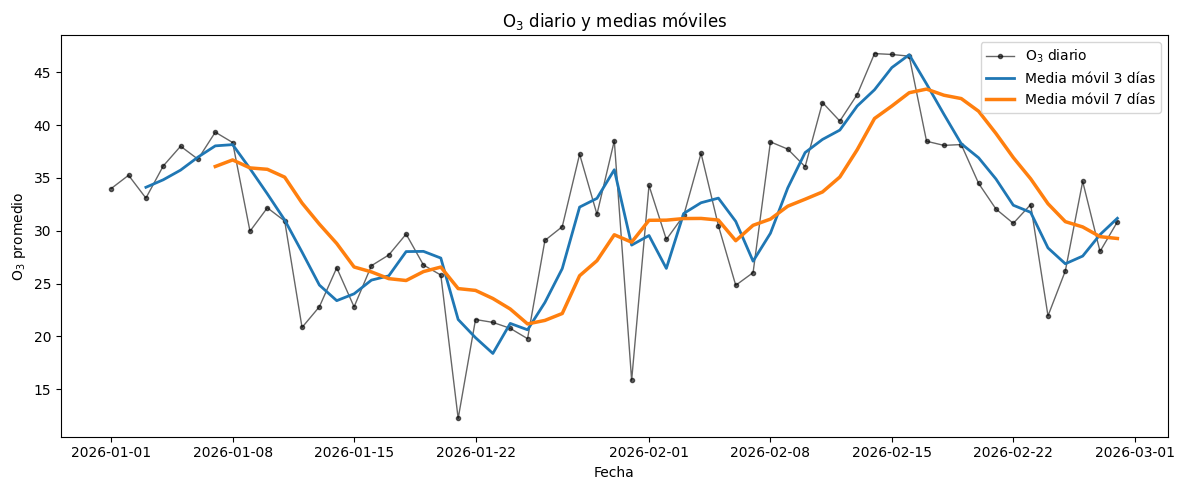

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    marker="o",
    markersize=3,
    linewidth=1,
    alpha=0.6,
    label="O$_3$ diario",
    color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_3d"],
    linewidth=2,
    label="Media móvil 3 días"
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_7d"],
    linewidth=2.5,
    label="Media móvil 7 días"
)

ax.set_title("O$_3$ diario y medias móviles")

ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.legend()

plt.tight_layout()
plt.show()

## Características temporales dentro de una ventana móvil

Una ventana temporal puede utilizarse para resumir distintos aspectos del comportamiento reciente de una serie.

Para una ventana de $w$ días,

$$
W_t^{(w)}=
\left\{
Y_t,
Y_{t-1},
\ldots,
Y_{t-w+1}
\right\},
$$

podemos calcular características como:

### Nivel local

La media móvil

$$
\mu_t^{(w)}=
\frac{1}{w}
\sum_{j=0}^{w-1}Y_{t-j}
$$

resume el nivel promedio reciente.

### Variabilidad local

La desviación estándar móvil

$$
\sigma_t^{(w)}=
\operatorname{sd}
\left(
W_t^{(w)}
\right)
$$

indica qué tanto han variado las observaciones recientes.

### Extremos locales

También podemos calcular

$$
\min(W_t^{(w)})
\qquad\text{y}\qquad
\max(W_t^{(w)}).
$$

A partir de ellos podemos definir el rango móvil:

$$
R_t^{(w)}=
\max(W_t^{(w)})-
\min(W_t^{(w)}).
$$

Un rango pequeño indica que la serie se ha mantenido relativamente estable durante la ventana, mientras que un rango grande indica mayor variación reciente.

Utilizaremos una ventana de

$$
w=7
$$

días para construir estas características en la serie de O$_3$.

In [22]:
# Ventana móvil de 7 días

ventana_o3_7d = serie_diaria["o3_promedio"].rolling(window=7,min_periods=7)

# Características temporales

serie_diaria["o3_mediana_7d"] = ventana_o3_7d.median()

serie_diaria["o3_std_7d"] = ventana_o3_7d.std()

serie_diaria["o3_min_7d"] = ventana_o3_7d.min()

serie_diaria["o3_max_7d"] = ventana_o3_7d.max()

serie_diaria["o3_rango_7d"] = serie_diaria["o3_max_7d"] - serie_diaria["o3_min_7d"]


display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "o3_media_7d",
            "o3_mediana_7d",
            "o3_std_7d",
            "o3_min_7d",
            "o3_max_7d",
            "o3_rango_7d"
        ]
    ].head(12)
)

,fecha,o3_promedio,o3_media_7d,o3_mediana_7d,o3_std_7d,o3_min_7d,o3_max_7d,o3_rango_7d
0,2026-01-01,33.989583,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-02,35.244792,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-03,33.083333,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-04,36.125000,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-05,37.993212,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-01-06,36.765121,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-01-07,39.322917,36.074851,36.125000,2.186914,33.083333,39.322917,6.239583
7,2026-01-08,38.343750,36.696875,36.765121,2.112925,33.083333,39.322917,6.239583
8,2026-01-09,29.947917,35.940179,36.765121,3.322110,29.947917,39.322917,9.375000
9,2026-01-10,32.166667,35.809226,36.765121,3.468339,29.947917,39.322917,9.375000


In [23]:
# Resumen de las características móviles

print("Resumen de las características móviles de 7 días:")

display(
    serie_diaria[
        [
            "o3_media_7d",
            "o3_mediana_7d",
            "o3_std_7d",
            "o3_min_7d",
            "o3_max_7d",
            "o3_rango_7d"
        ]
    ]
    .describe()
    .round(2)
)

Resumen de las características móviles de 7 días:


,o3_media_7d,o3_mediana_7d,o3_std_7d,o3_min_7d,o3_max_7d,o3_rango_7d
count,53.00,53.00,53.00,53.00,53.00,53.00
mean,31.62,32.11,5.17,23.37,37.79,14.42
std,6.01,5.96,1.59,7.78,5.65,4.86
min,21.18,21.32,2.08,12.23,26.75,6.24
25%,26.57,26.69,4.00,15.84,34.66,10.70
50%,31.00,31.55,5.26,21.94,38.46,14.52
75%,35.81,36.77,6.37,29.95,39.32,17.46
max,43.40,42.88,8.41,38.46,46.76,22.67


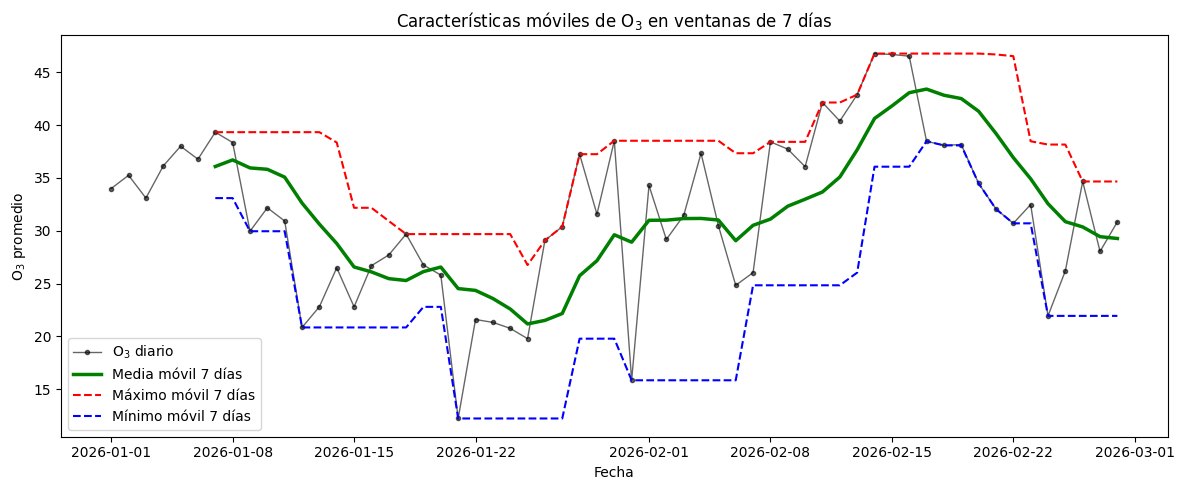

In [24]:
# Visualización del intervalo local de los últimos 7 días

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    marker="o",
    markersize=3,
    linewidth=1,
    alpha=0.6,
    label="O$_3$ diario", color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_7d"],
    linewidth=2.5,
    label="Media móvil 7 días", color='green'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_max_7d"],
    linestyle="--",
    linewidth=1.5,
    label="Máximo móvil 7 días",color='red'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_min_7d"],
    linestyle="--",
    linewidth=1.5,
    label="Mínimo móvil 7 días",color='blue'
)

ax.set_title("Características móviles de O$_3$ en ventanas de 7 días")
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.legend()

plt.tight_layout()
plt.show()